<a href="https://colab.research.google.com/github/lasyayakkala12-hash/Bridge-Load-Distribution-Calculator-/blob/main/Bring_load_distribution_calculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Bridge Load Distribution Calculator")

Bridge Load Distribution Calculator


In [2]:
# Bridge length
L = float(input("Enter bridge length: "))

# Number of loads
n = int(input("Enter number of loads: "))

loads = []

for i in range(n):
    P = float(input(f"Enter load {i+1}: "))
    x = float(input(f"Enter position of load {i+1} from support A: "))
    loads.append((P, x))

print("\nInput completed.")

Enter bridge length: 10
Enter number of loads: 1
Enter load 1: 2
Enter position of load 1 from support A: 5

Input completed.


In [3]:
# Total load
total_load = sum(P for P, x in loads)

# Sum of moments about A
moment_A = sum(P * x for P, x in loads)

# Matrix equation AX = B
A = np.array([
    [1, 1],
    [0, L]
], dtype=float)

B = np.array([
    total_load,
    moment_A
], dtype=float)

# Solve for reactions
R_A, R_B = np.linalg.solve(A, B)

print("\nMATHEMATICAL CALCULATION")
print("------------------------")

print("A =")
print(A)

print("\nX = [R_A, R_B]")

print("\nB =")
print(B)

print("\nTherefore:")
print(f"R_A = {R_A:.2f}")
print(f"R_B = {R_B:.2f}")


MATHEMATICAL CALCULATION
------------------------
A =
[[ 1.  1.]
 [ 0. 10.]]

X = [R_A, R_B]

B =
[ 2. 10.]

Therefore:
R_A = 1.00
R_B = 1.00


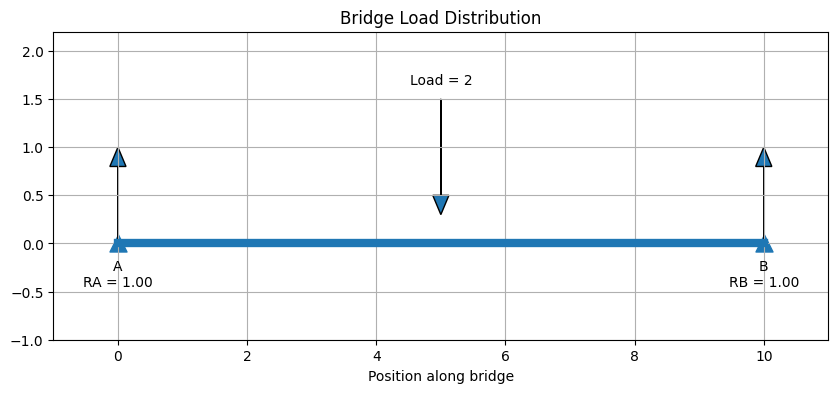

In [4]:
# Draw the bridge
plt.figure(figsize=(10, 4))

# Bridge deck
plt.plot([0, L], [0, 0], linewidth=6)

# Supports
plt.scatter([0, L], [0, 0], s=150, marker="^")

# Draw loads
for P, x in loads:
    plt.arrow(
        x, 1.5, 0, -1.2,
        head_width=0.25,
        head_length=0.2,
        length_includes_head=True
    )
    plt.text(x, 1.65, f"Load = {P:g}", ha="center")

# Draw reactions
plt.arrow(
    0, 0, 0, 1.0,
    head_width=0.25,
    head_length=0.2,
    length_includes_head=True
)

plt.arrow(
    L, 0, 0, 1.0,
    head_width=0.25,
    head_length=0.2,
    length_includes_head=True
)

plt.text(0, -0.45, f"A\nRA = {R_A:.2f}", ha="center")
plt.text(L, -0.45, f"B\nRB = {R_B:.2f}", ha="center")

plt.xlim(-1, L + 1)
plt.ylim(-1, 2.2)
plt.xlabel("Position along bridge")
plt.title("Bridge Load Distribution")
plt.grid(True)

plt.show()